In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [2]:
%matplotlib inline

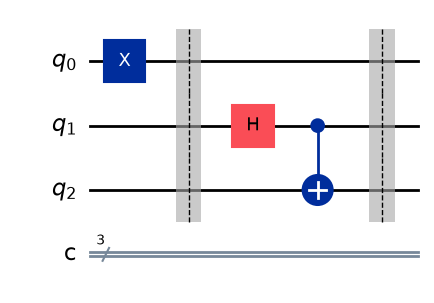

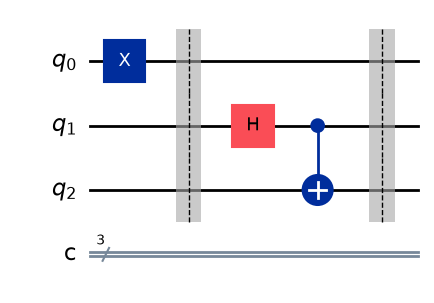

In [3]:
circuit = QuantumCircuit(3,3)

circuit.x(0)
circuit.barrier()

circuit.h(1)
circuit.cx(1,2)

circuit.barrier()

circuit.draw(output="mpl")

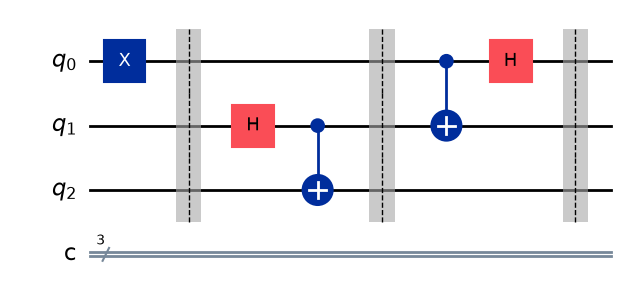

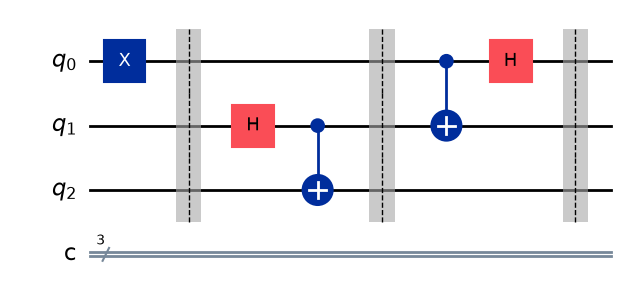

In [4]:
circuit.cx(0,1)
circuit.h(0)

circuit.barrier()

circuit.draw(output="mpl")

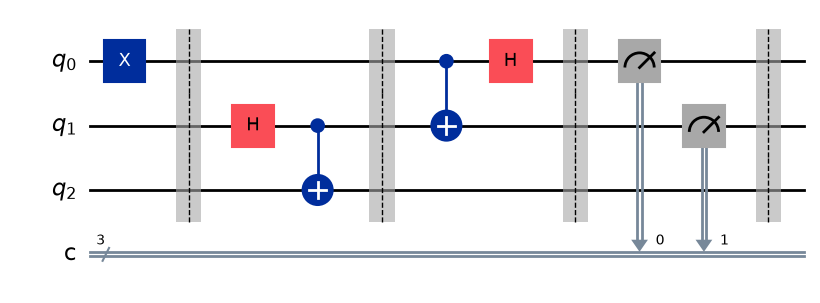

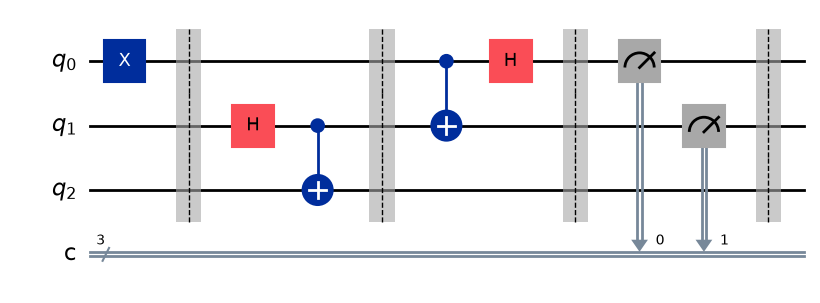

In [5]:
circuit.measure([0,1], [0,1])

circuit.barrier()

circuit.draw(output="mpl")

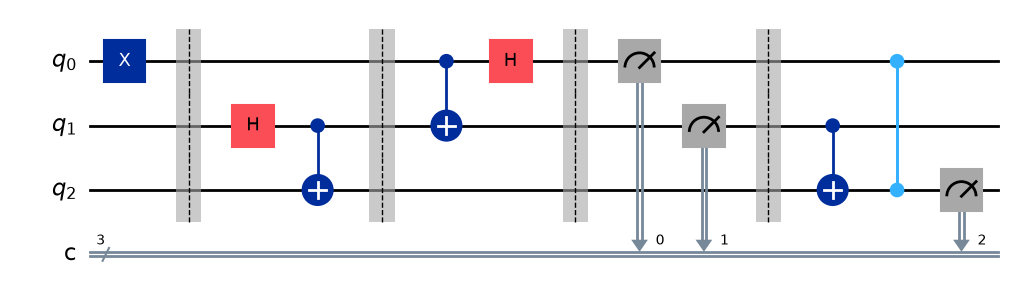

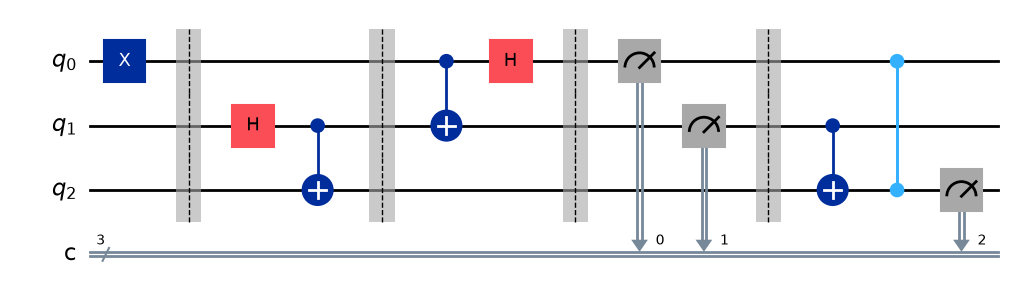

In [6]:
circuit.cx(1,2)
circuit.cz(0,2)

circuit.measure([2], [2])

circuit.draw(output="mpl")

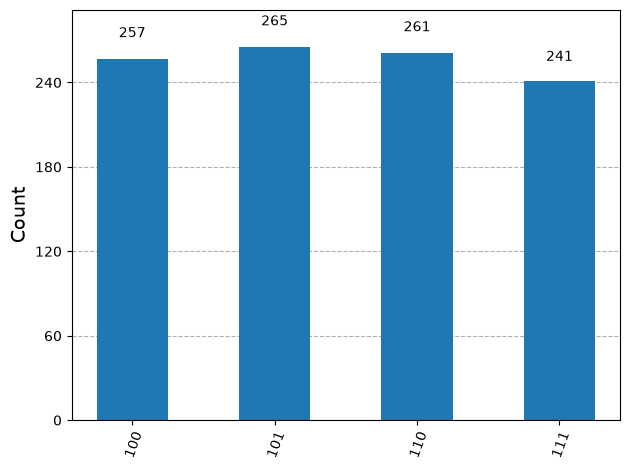

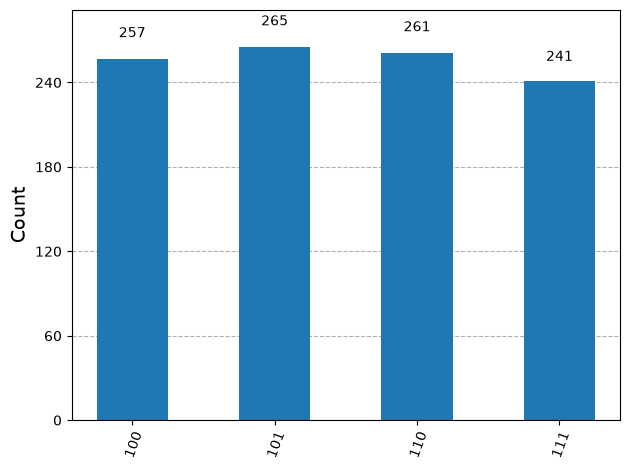

In [7]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots = 1024).result()
plot_histogram(result.get_counts(circuit))

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="ENTER YOUR OWN API KEY",
    instance="ENTER YOUR OWN INSTANCE NAME",
    overwrite=True
)

service = QiskitRuntimeService()

In [11]:
print("Available backends:")
for backend in service.backends():
    print(" -", backend.name)

Available backends:
 - ibm_fez
 - ibm_kingston
 - ibm_marrakesh


In [13]:
quantum_computer = service.least_busy(operational=True, simulator=False)

In [14]:
print("Selected Backend:", quantum_computer.name)

Selected Backend: ibm_kingston


In [15]:
from qiskit_ibm_runtime.executor_sampler import Sampler

In [16]:
isa_circuit = transpile(circuit, backend=quantum_computer, optimization_level=1)

sampler = Sampler(mode=quantum_computer)
job = sampler.run([isa_circuit], shots=1024)
print(job.job_id())

dasq945vr3kc73ekf470


In [17]:
print("Status Before Waiting:", job.status())
result = job.result()
print("Status After Waiting :", job.status())

Status Before Waiting: QUEUED
Status After Waiting : DONE


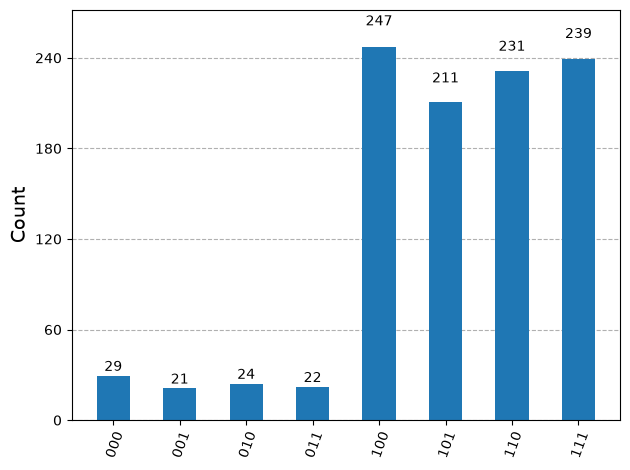

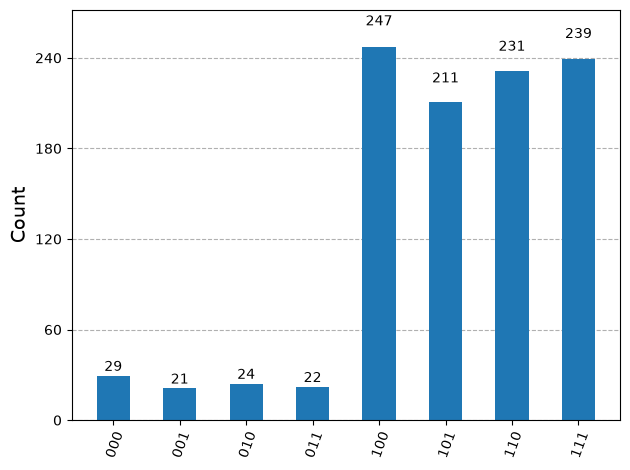

In [18]:
counts = result[0].data.c.get_counts()
plot_histogram(counts)